In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
from scipy.optimize import fsolve
import math

In [4]:
df = pd.read_parquet("overnight_erdos_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7920 entries, 0 to 7919
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   n                 7920 non-null   int64  
 1   p                 7920 non-null   float64
 2   largest_fraction  7920 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 185.8 KB


In [9]:
fig = px.histogram(df, x = df['largest_fraction'])
fig.show()

In [21]:
pivot = df.pivot(index = 'n', columns = 'p', values = 'largest_fraction')
fig = go.Figure(data = go.Surface(
    z = pivot.values,
    x = df['p'].unique(),
    y = df['n'].unique(),
    colorscale = 'Blackbody',
    colorbar_title = 'Largest Fraction'
)
)

fig.update_layout(
    title = 'Largest Fraction of Connected Component in Erdos-Renyi Graphs',
    scene = dict(
        xaxis_title = 'Probability of Edge Creation (p)',
        xaxis_type = 'log', # Make sure probability is in log scale
        yaxis_title = 'Number of Nodes (n)',
        zaxis_title = 'Largest Fraction of Connected Component'
    ),
    width = 800,
    height = 800,
    margin = dict(l = 0, r = 0, b = 0, t = 0)
)

fig.show()

Running simulation for n = 100...
Running simulation for n = 500...


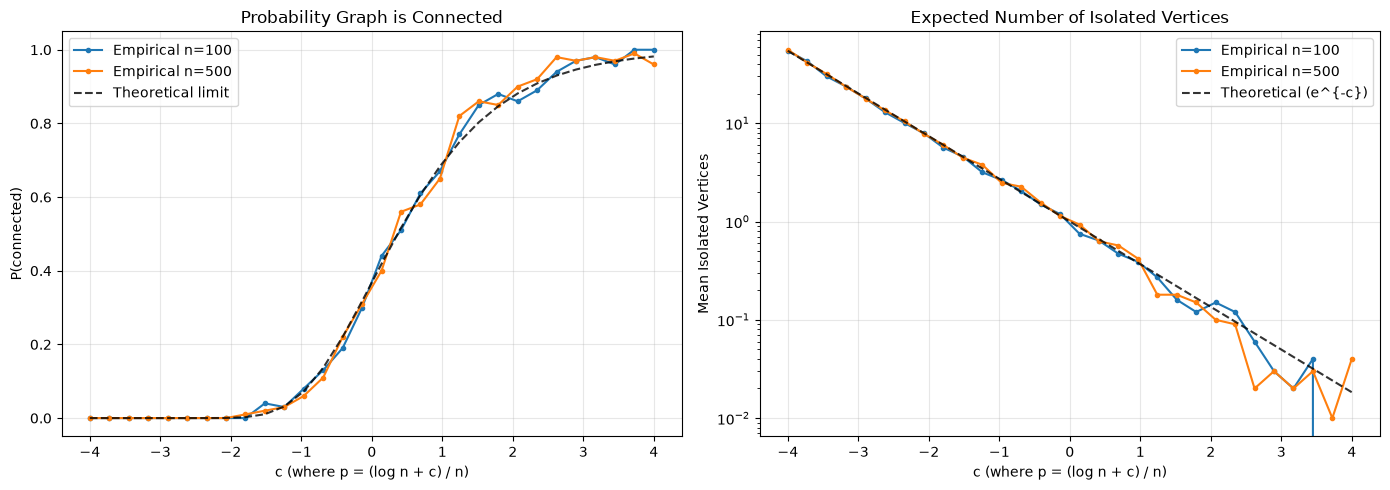

In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def simulate_connectivity(n_values, c_values, trials=50):
    """
    Simulates connectivity and isolated vertices in Erdos-Renyi graphs.
    """
    results = {
        n: {'p_connected': [], 'mean_isolated': []} 
        for n in n_values
    }
    
    for n in n_values:
        print(f"Running simulation for n = {n}...")
        for c in c_values:
            # The critical scaling for connectivity
            p = (np.log(n) + c) / n 
            
            # Cap p at 1.0 (though unlikely to exceed unless n is very small and c is huge)
            p = min(p, 1.0)
            
            connected_count = 0
            isolated_sum = 0
            
            for _ in range(trials):
                G = nx.erdos_renyi_graph(n, p)
                
                # Check if fully connected
                if nx.is_connected(G):
                    connected_count += 1
                    
                # Count isolated vertices (degree == 0)
                isolates = list(nx.isolates(G))
                isolated_sum += len(isolates)
                
            results[n]['p_connected'].append(connected_count / trials)
            results[n]['mean_isolated'].append(isolated_sum / trials)
            
    return results

# --- Parameters ---
n_values = [100, 500]             # Network sizes to compare
c_values = np.linspace(-4, 4, 30) # Sweep c around 0
trials = 100                      # Number of graphs per data point

# --- Run Simulation ---
data = simulate_connectivity(n_values, c_values, trials)

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Probability of Connectivity
for n in n_values:
    ax1.plot(c_values, data[n]['p_connected'], marker='.', label=f'Empirical n={n}')

# Theoretical P(connected) = e^{-e^{-c}}
theoretical_p_conn = np.exp(-np.exp(-c_values))
ax1.plot(c_values, theoretical_p_conn, 'k--', label='Theoretical limit', alpha=0.8)

ax1.set_title('Probability Graph is Connected')
ax1.set_xlabel('c (where p = (log n + c) / n)')
ax1.set_ylabel('P(connected)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Mean Isolated Vertices
for n in n_values:
    ax2.plot(c_values, data[n]['mean_isolated'], marker='.', label=f'Empirical n={n}')

# Theoretical E[Isolated] = e^{-c}
theoretical_iso = np.exp(-c_values)
ax2.plot(c_values, theoretical_iso, 'k--', label='Theoretical (e^{-c})', alpha=0.8)

ax2.set_title('Expected Number of Isolated Vertices')
ax2.set_xlabel('c (where p = (log n + c) / n)')
ax2.set_ylabel('Mean Isolated Vertices')
ax2.set_yscale('log') # Log scale helps visualize the exponential decay
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Running Monte Carlo Simulation...


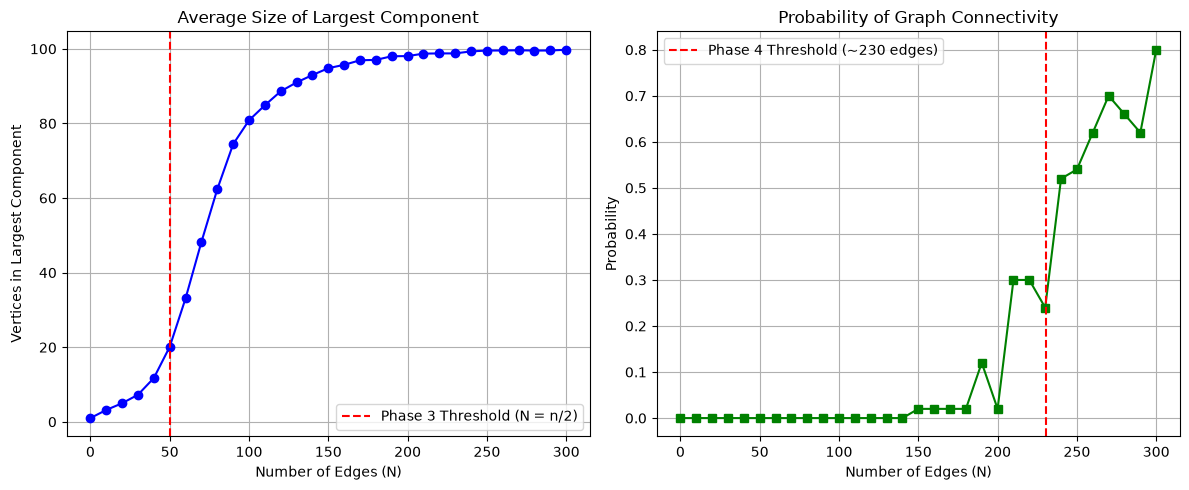

Generating graphical examples for each phase...


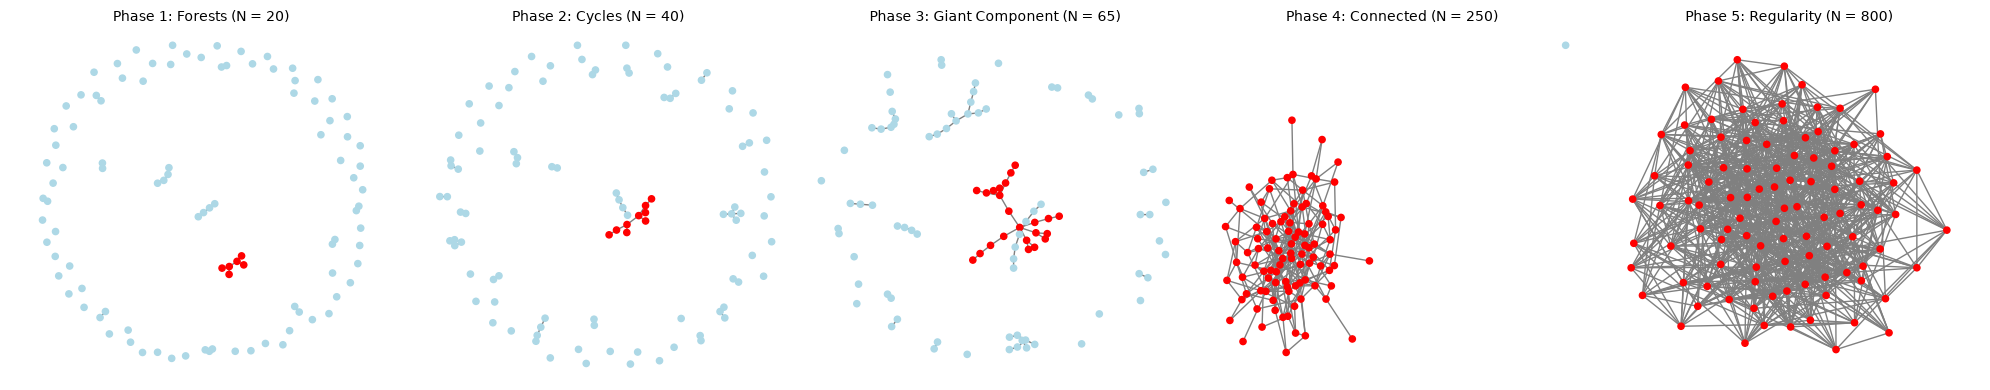

In [6]:
def run_monte_carlo_simulation():
    """
    Runs a Monte Carlo simulation to track the size of the largest component
    and the probability of connectivity as the number of edges (N) increases.
    """
    n = 100 # Number of vertices
    trials = 50 # Number of random graphs generated per N value
    
    # Sweep N from 0 to 300 edges
    N_values = np.linspace(0, 300, 31, dtype=int)
    
    avg_largest_component = []
    prob_connected = []

    print("Running Monte Carlo Simulation...")
    for N in N_values:
        largest_comp_sizes = []
        connected_count = 0
        
        for _ in range(trials):
            # Generate a random graph with n vertices and N edges
            G = nx.gnm_random_graph(n, N)
            
            # Find the size of the largest connected component
            largest_cc = max(nx.connected_components(G), key=len)
            largest_comp_sizes.append(len(largest_cc))
            
            # Check if the entire graph is connected
            if nx.is_connected(G):
                connected_count += 1
                
        avg_largest_component.append(np.mean(largest_comp_sizes))
        prob_connected.append(connected_count / trials)

    # Plot the Monte Carlo Results
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Size of Largest Component (Demonstrating Phase 3)
    plt.subplot(1, 2, 1)
    plt.plot(N_values, avg_largest_component, marker='o', color='b')
    plt.axvline(x=n/2, color='r', linestyle='--', label='Phase 3 Threshold (N = n/2)')
    plt.title("Average Size of Largest Component")
    plt.xlabel("Number of Edges (N)")
    plt.ylabel("Vertices in Largest Component")
    plt.legend()
    plt.grid(True)

    # Plot 2: Probability of Connectivity (Demonstrating Phase 4)
    plt.subplot(1, 2, 2)
    plt.plot(N_values, prob_connected, marker='s', color='g')
    
    # Phase 4 Threshold: N = (n/2) * ln(n)
    phase4_threshold = (n / 2) * math.log(n)
    plt.axvline(x=phase4_threshold, color='r', linestyle='--', label=f'Phase 4 Threshold (~{int(phase4_threshold)} edges)')
    plt.title("Probability of Graph Connectivity")
    plt.xlabel("Number of Edges (N)")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def visualize_five_phases():
    """
    Generates and plots a single visual example of the graph structure 
    at each of the 5 phases described by Erdős and Rényi.
    """
    n = 100
    
    # Define characteristic edge counts (N) for each phase based on the paper's thresholds
    phases = {
        "Phase 1: Forests (N = 20)": 20,                                # N = o(n)
        "Phase 2: Cycles (N = 40)": 40,                                 # N ~ cn, c < 1/2
        "Phase 3: Giant Component (N = 65)": 65,                        # N ~ cn, c > 1/2
        "Phase 4: Connected (N = 250)": int((n/2) * math.log(n) + 20),  # N ~ (n/2)ln(n)
        "Phase 5: Regularity (N = 800)": 800                            # N >> n ln(n)
    }

    plt.figure(figsize=(20, 4))
    
    print("Generating graphical examples for each phase...")
    for i, (title, N) in enumerate(phases.items(), 1):
        plt.subplot(1, 5, i)
        G = nx.gnm_random_graph(n, N)
        
        # Color the largest component differently to highlight Phase 3
        largest_cc = max(nx.connected_components(G), key=len)
        colors = ['red' if node in largest_cc else 'lightblue' for node in G.nodes()]
        
        # Use a spring layout for better visual clustering
        pos = nx.spring_layout(G, seed=42)
        nx.draw(G, pos, node_size=20, node_color=colors, edge_color='gray', with_labels=False)
        plt.title(title, fontsize=10)

    plt.tight_layout()
    plt.show()


run_monte_carlo_simulation()
visualize_five_phases()